#### Exploring Data

In [1]:
# import libraries 
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# read data file and create data frame
gm = pd.read_csv('./gapminder.csv')

#### Sanity Checks

In [3]:
gm.shape

(41822, 8)

In [4]:
gm.head(5)

,country,year,region,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
0,Afghanistan,1800,Asia,3280000.0,28.2,53.1,7.0,599.0
1,Afghanistan,1806,Asia,3280000.0,28.1,53.0,7.0,599.0
2,Afghanistan,1816,Asia,3280000.0,28.1,52.9,7.0,599.0
3,Afghanistan,1817,Asia,3280000.0,28.0,52.9,7.0,599.0
4,Afghanistan,1820,Asia,3290000.0,28.0,52.9,7.0,599.0


In [5]:
gm.tail(5)

,country,year,region,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
41817,Zimbabwe,2019,Africa,15300000.0,61.0,95.56,3.75,2200.0
41818,Zimbabwe,2020,Africa,15500000.0,60.9,95.69,3.75,1990.0
41819,Zimbabwe,2021,Africa,15800000.0,59.0,95.80,3.77,2120.0
41820,Zimbabwe,2022,Africa,16100000.0,59.1,95.87,3.77,2140.0
41821,Zimbabwe,2023,Africa,16300000.0,61.7,95.94,3.72,2180.0


In [6]:
gm.info()

<class 'pandas.DataFrame'>
RangeIndex: 41822 entries, 0 to 41821
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           41822 non-null  str    
 1   year              41822 non-null  int64  
 2   region            41822 non-null  str    
 3   population        41822 non-null  float64
 4   life_expectancy   40629 non-null  float64
 5   age5_surviving    40490 non-null  float64
 6   babies_per_woman  41822 non-null  float64
 7   gdp_per_capita    41822 non-null  float64
dtypes: float64(5), int64(1), str(2)
memory usage: 2.6 MB


In [7]:
gm.describe()

,year,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
count,41822.000000,4.182200e+04,40629.000000,40490.000000,41822.000000,41822.000000
mean,1915.563818,1.414338e+07,45.147504,72.596526,5.242053,6124.325212
std,62.938582,6.871230e+07,16.831495,16.604898,1.728142,12328.127667
min,1800.000000,1.830000e+03,0.000000,24.400000,0.710000,386.000000
25%,1862.000000,3.310000e+05,32.000000,58.400000,4.220000,1220.000000
50%,1916.000000,1.920000e+06,37.300000,66.700000,5.810000,2100.000000
75%,1970.000000,6.617500e+06,60.100000,89.600000,6.550000,4970.000000
max,2023.000000,1.440000e+09,85.400000,99.857000,8.860000,218000.000000


In [8]:
gm.sample(5)

,country,year,region,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
10052,Denmark,1940,Europe,3850000.0,66.5,94.11,2.22,11600.0
9569,Cyprus,1900,Asia,237000.0,40.6,69.80,4.17,2590.0
17032,Iran,1873,Asia,8490000.0,25.5,49.40,7.08,1390.0
20775,Liberia,1971,Africa,1500000.0,45.8,71.80,6.54,5580.0
3038,Bangladesh,2001,Asia,137000000.0,66.0,91.73,3.20,2320.0


In [9]:
# read another data file and create data frame
incomes = pd.read_csv('./incomes.csv')

In [10]:
incomes.shape

(4000, 3)

In [11]:
incomes.head(5)

,country,year,yearly
0,China,1965,374.584412
1,China,1965,332.899298
2,China,1965,40.405060
3,China,1965,171.425536
4,China,1965,136.738420


In [12]:
incomes.tail(5)

,country,year,yearly
3995,USA,2015,17830.112511
3996,USA,2015,12448.307718
3997,USA,2015,87588.746752
3998,USA,2015,5597.465988
3999,USA,2015,36709.679066


In [13]:
incomes.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  4000 non-null   str    
 1   year     4000 non-null   int64  
 2   yearly   4000 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 93.9 KB


In [14]:
incomes.describe()

,year,yearly
count,4000.000000,4000.000000
mean,1990.000000,9395.478736
std,25.003126,13605.455635
min,1965.000000,15.318452
25%,1965.000000,707.476317
50%,1990.000000,5112.191075
75%,2015.000000,12513.658506
max,2015.000000,256054.350614


In [15]:
incomes.sample(10)

,country,year,yearly
1823,China,2015,10115.446261
1252,China,2015,2194.542550
1160,China,2015,2776.599418
613,China,1965,46.694848
1496,China,2015,1923.090770
3324,USA,2015,4152.526798
3993,USA,2015,2857.540400
3089,USA,2015,52551.811350
3172,USA,2015,6353.949447
2759,USA,1965,12214.891193


In [16]:
# how many countries are there
incomes.country.unique()

<StringArray>
['China', 'USA']
Length: 2, dtype: str

In [17]:
# how many years are there
incomes.year.unique()

array([1965, 2015])

#### Summarizing Data Distributions 

In [18]:
# reset the index
incomes = pd.read_csv('./incomes.csv').set_index(['country', 'year'])
incomes

yearly
country year              
China   1965    374.584412
        1965    332.899298
        1965     40.405060
        1965    171.425536
        1965    136.738420
...                    ...
USA     2015  17830.112511
        2015  12448.307718
        2015  87588.746752
        2015   5597.465988
        2015  36709.679066

[4000 rows x 1 columns]

In [19]:
# find count by country and year
incomes.groupby(['country','year']).count()

yearly
country year        
China   1965    1000
        2015    1000
USA     1965    1000
        2015    1000

#### Simple Statistics of the Data

In [20]:
# import statistics package
import scipy.stats

In [21]:
incomes.loc['USA', 2015].min()

yearly    1782.58948
dtype: float64

In [22]:
incomes.loc['USA', 2015].max()

yearly    256054.350614
dtype: float64

In [23]:
incomes.groupby(['country', 'year']).yearly.mean()

country  year
China    1965      241.117733
         2015     3651.785585
USA      1965    11529.607090
         2015    22159.404538
Name: yearly, dtype: float64

In [24]:
incomes.groupby(['country', 'year']).var()

yearly
country year              
China   1965  2.785142e+04
        2015  7.657566e+06
USA     1965  6.507744e+07
        2015  3.836775e+08

In [25]:
incomes.groupby(['country', 'year']).std()

yearly
country year              
China   1965    166.887455
        2015   2767.230725
USA     1965   8067.058766
        2015  19587.688162

In [26]:
pd.DataFrame({'25%': incomes.groupby(['country', 'year']).yearly.quantile(0.25),
              '50%': incomes.groupby(['country', 'year']).yearly.median(),
              '75%': incomes.groupby(['country', 'year']).yearly.quantile(0.75)})

25%           50%           75%
country year                                          
China   1965    125.607498    203.478954    315.248787
        2015   1839.690284   2869.259934   4659.306189
USA     1965   6386.986126   9515.378686  14241.246328
        2015  10771.205045  16859.098812  26648.526889

In [27]:
# interpret the query and results
incomes.groupby(['country', 'year']).yearly.apply(lambda d: scipy.stats.percentileofscore(d, 5000))

country  year
China    1965    100.0
         2015     79.8
USA      1965     13.7
         2015      4.5
Name: yearly, dtype: float64

In [28]:
# interpret the query and the results
incomes.groupby(['year', 'country']).yearly.describe() / incomes.loc['USA', 2015].yearly.describe()

count      mean       std       min       25%       50%  \
year country                                                            
1965 China      1.0  0.010881  0.008520  0.008593  0.011661  0.012069   
     USA        1.0  0.520303  0.411843  0.855450  0.592969  0.564406   
2015 China      1.0  0.164796  0.141274  0.104280  0.170797  0.170191   
     USA        1.0  1.000000  1.000000  1.000000  1.000000  1.000000   

                   75%       max  
year country                      
1965 China    0.011830  0.007736  
     USA      0.534410  0.350711  
2015 China    0.174843  0.076493  
     USA      1.000000  1.000000

#### Visualizing Data Distributions

In [29]:
# import libraries
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
# read file and reset index
incomes = pd.read_csv('./incomes.csv').set_index(['country', 'year'])

In [31]:
# add column
incomes['log10_daily'] = np.log10(incomes.yearly / 365.25)

In [32]:
# check the data frame
incomes

yearly  log10_daily
country year                           
China   1965    374.584412     0.010959
        1965    332.899298    -0.040277
        1965     40.405060    -0.956154
        1965    171.425536    -0.328515
        1965    136.738420    -0.426700
...                    ...          ...
USA     2015  17830.112511     1.688564
        2015  12448.307718     1.532520
        2015  87588.746752     2.379858
        2015   5597.465988     1.185401
        2015  36709.679066     2.002190

[4000 rows x 2 columns]

#### Create Visuals and Interpret the Results

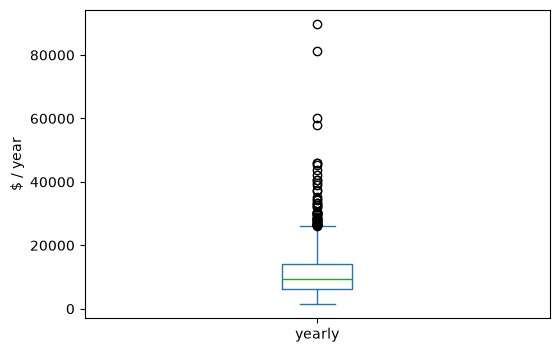

In [33]:
# create box plot
incomes.loc['USA', 1965].yearly.plot(kind='box', figsize=(6,4));
plt.ylabel('$ / year');

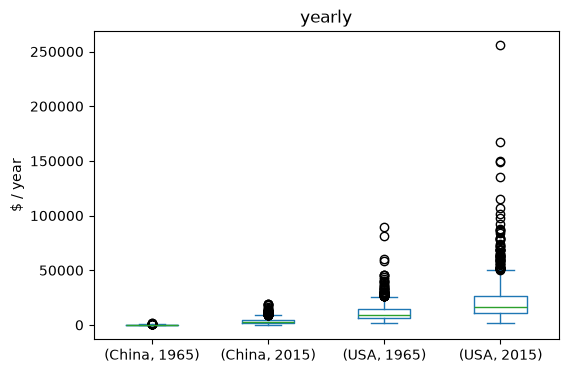

In [34]:
# box plot for both countries and years
incomes.reset_index().plot(kind='box', column='yearly', by=['country', 'year'], figsize=(6,4))
plt.ylabel('$ / year');

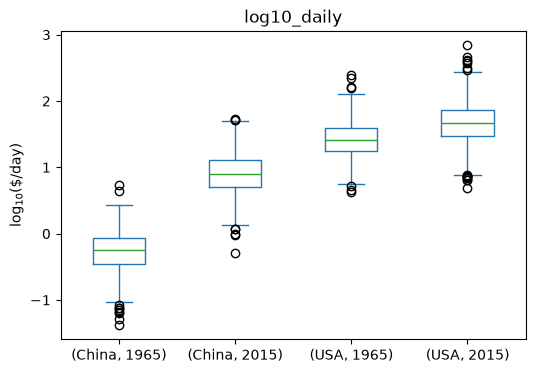

In [35]:
# labels support the LaTeX math language
incomes.reset_index().plot(kind='box', column='log10_daily', by=['country', 'year'], figsize=(6,4))
plt.ylabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$');  

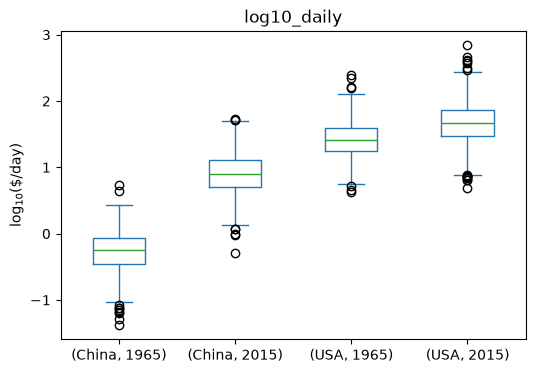

In [36]:
# labels support the LaTeX math language
incomes.reset_index().plot(kind='box', column='log10_daily', by=['country', 'year'], figsize=(6,4))
plt.ylabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$'); 

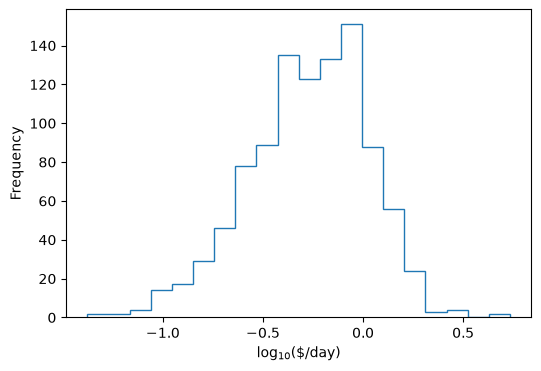

In [37]:
# histtype = 'step' removes the color fill
incomes.loc['China', 1965].log10_daily.plot(kind='hist', histtype='step', bins=20, figsize=(6,4))
plt.xlabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$');

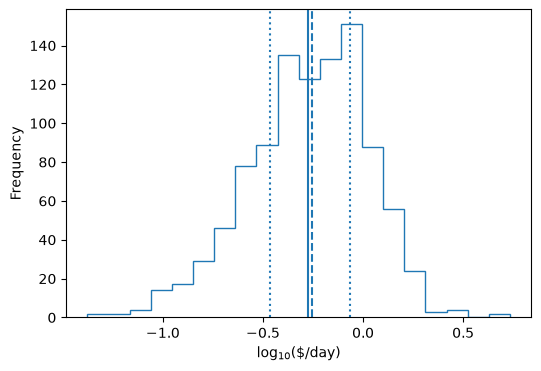

In [38]:
data = incomes.loc['China', 1965].log10_daily
data.plot(kind='hist', histtype='step', bins=20, figsize=(6,4))

plt.xlabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$')

plt.axvline(data.mean())
plt.axvline(data.median(), linestyle='--')
plt.axvline(data.quantile(0.25), linestyle=':')
plt.axvline(data.quantile(0.75), linestyle=':');

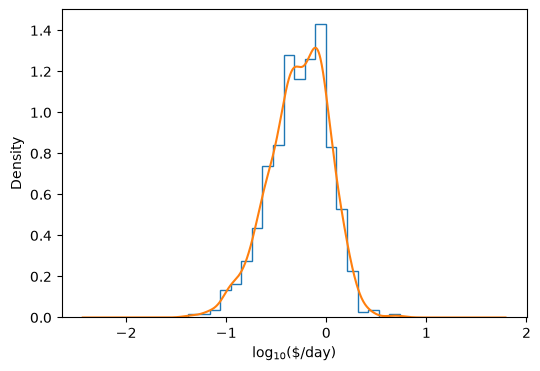

In [39]:
data.plot.hist(histtype='step', bins=20, density=True, figsize=(6,4))
data.plot.density()
plt.xlabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$');

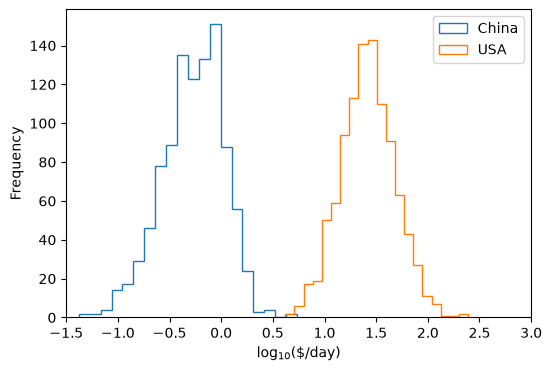

In [40]:
incomes.loc['China', 1965].log10_daily.plot(kind='hist', histtype='step', bins=20, figsize=(6,4), label='China');
incomes.loc['USA', 1965].log10_daily.plot(kind='hist', histtype='step', bins=20, label='USA')
plt.axis(xmin=-1.5, xmax=3)
plt.xlabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$'); plt.legend();

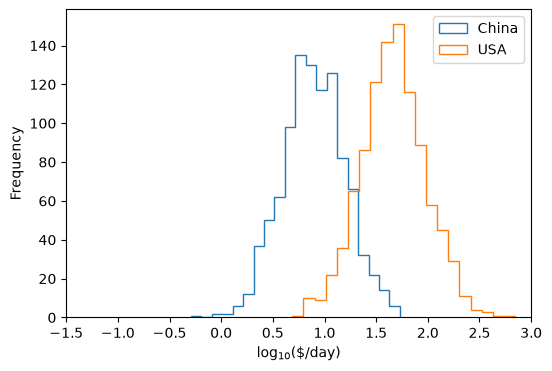

In [41]:
incomes.loc['China', 2015].log10_daily.plot(kind='hist', histtype='step', bins=20, figsize=(6,4), label='China');
incomes.loc['USA', 2015].log10_daily.plot(kind='hist', histtype='step', bins=20, label='USA')
plt.axis(xmin=-1.5, xmax=3)
plt.xlabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$'); plt.legend();

#### Combine Population Data with Income

In [42]:
gm = pd.read_csv('./gapminder.csv')

In [43]:
data = incomes.loc["China", 2015].log10_daily

In [44]:
gm.query('country == "China" and year == 2015').population

7781    1.400000e+09
Name: population, dtype: float64

In [45]:
weights = gm.query('country == "China" and year == 2015').population.iloc[0] * np.ones_like(data) / len(data)

In [46]:
weights[0]

np.float64(1400000.0)

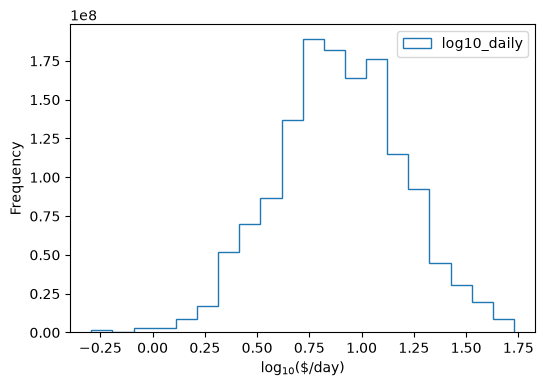

In [47]:
data.plot(kind='hist', histtype='step', bins=20, figsize=(6,4), weights=weights)
plt.xlabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$'); plt.legend();

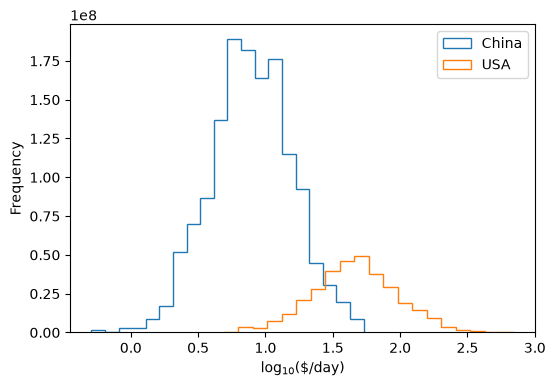

In [48]:
for country in ['China', 'USA']:
    data = incomes.loc[country, 2015].log10_daily
    
    population = gm.query('country == @country and year == 2015').population.iloc[0]
    weights = population * np.ones_like(data) / len(data)
    
    data.plot(kind='hist', histtype='step', bins=20, figsize=(6,4), weights=weights, label=country);

plt.xlabel(r'$\mathrm{log}_{10} (\$ / \mathrm{day})$'); plt.legend();

#### Use Seaborn for Visualization

In [49]:
# import seaborn
import seaborn as sns

In [50]:
# silence pandas warnings about methods that will change in the future
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [51]:
data_2015 = incomes.loc[pd.IndexSlice[:,2015], :].reset_index()

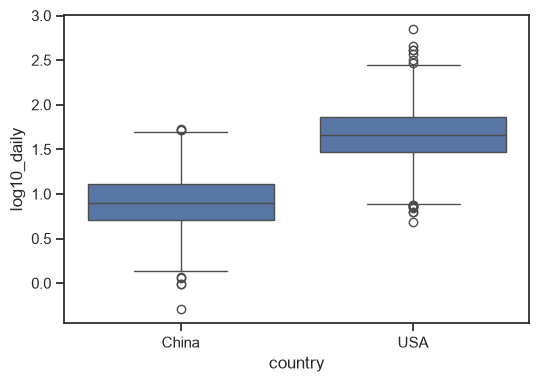

In [52]:
sns.set(style='ticks') # could be white, dark, whitegrid, darkgrid, ticks  
plt.figure(figsize=(6,4))
sns.boxplot(data=data_2015, x='country', y='log10_daily');

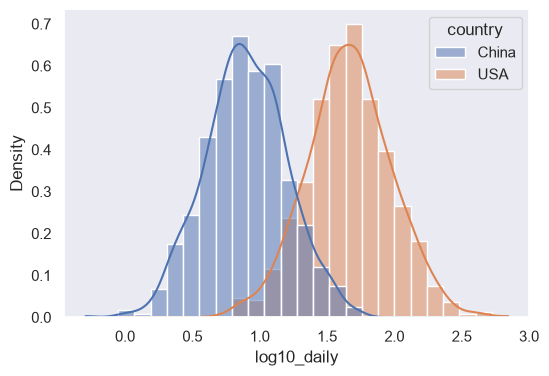

In [53]:
sns.set(style='dark')
plt.figure(figsize=(6,4))
sns.histplot(data=data_2015, x='log10_daily', hue='country', stat='density', kde=True);

#### Comparing Quantitative Data Variables

In [54]:
# import libraries
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
gm = pd.read_csv('./gapminder.csv')

In [56]:
gm.sample(10)

,country,year,region,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
1345,Argentina,1830,America,635000.0,33.2,59.8,6.80,2450.0
32659,Singapore,1893,Asia,170000.0,33.7,60.8,5.64,2840.0
33264,Solomon Islands,1862,Oceania,89800.0,24.9,49.5,6.42,602.0
30746,Rwanda,1883,Africa,1570000.0,30.9,58.0,7.07,917.0
39114,UAE,1927,Asia,60300.0,40.5,59.1,6.94,3100.0
13466,Gambia,1975,Africa,607000.0,57.0,73.6,6.43,2360.0
2284,Azerbaijan,1877,Asia,1520000.0,25.0,67.2,8.10,1240.0
30557,Russia,1918,Europe,76900000.0,25.6,66.5,5.72,1720.0
40346,Uzbekistan,1849,Asia,2500000.0,26.9,62.0,5.71,805.0
22635,Malta,1929,Europe,228000.0,53.8,87.3,4.56,2660.0


In [57]:
# get information for a single country
italy = gm.query('country == "Italy"')

In [58]:
italy.sample(5)

,country,year,region,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
17920,Italy,1933,Europe,41200000.0,56.4,85.000,3.05,6440.0
17997,Italy,2010,Europe,60200000.0,82.1,99.603,1.44,42700.0
17893,Italy,1906,Europe,34900000.0,45.1,73.400,4.45,5210.0
17894,Italy,1907,Europe,35200000.0,45.5,74.500,4.46,5300.0
17844,Italy,1857,Europe,25500000.0,29.7,54.900,5.15,3670.0


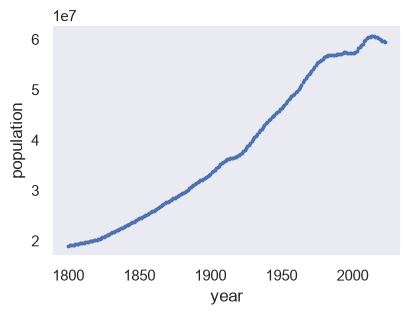

In [59]:
# create a scatter plot
italy.plot.scatter(x='year', y='population', s=3, figsize=(4.5,3));

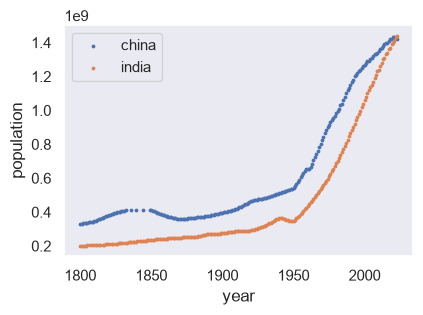

In [60]:
# population growth of China and India
axes = gm.query('country == "China"').plot.scatter(x='year', y='population', label='china', c='C0', s=3, figsize=(4.5,3))
gm.query('country == "India"').plot.scatter(x='year', y='population', label='india', c='C1', s=3, ax=axes); # reuse axes

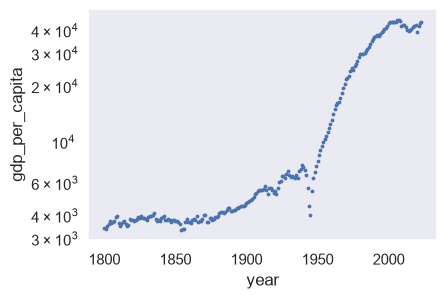

In [61]:
italy.plot.scatter('year', 'gdp_per_capita', logy=True, s=3, figsize=(4.5,3));

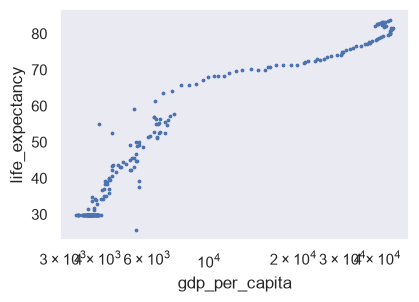

In [62]:
italy.plot.scatter(x='gdp_per_capita', y='life_expectancy', logx=True, s=3, figsize=(4.5,3));

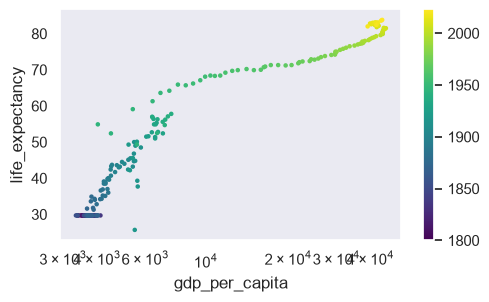

In [63]:
italy.plot.scatter(x='gdp_per_capita', y='life_expectancy', logx=True, c=italy.year,
                   colormap='viridis', s=5, figsize=(5.5,3));

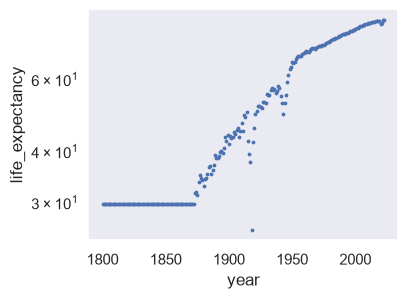

In [64]:
italy.plot.scatter('year', 'life_expectancy', logy=True, s=3, figsize=(4,3));

In [65]:
# data for the year 2015
gm2015 = gm[gm.year == 2015]

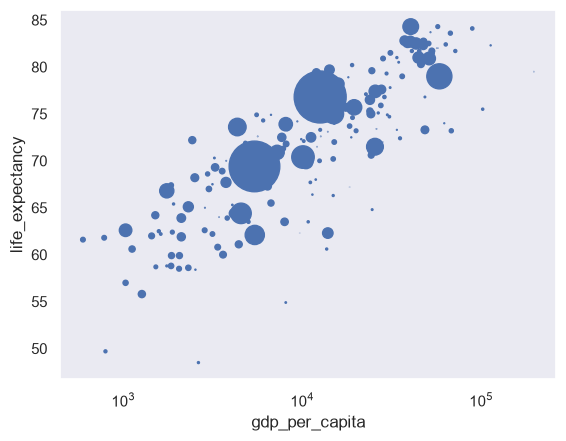

In [66]:
gm2015.plot.scatter(x='gdp_per_capita', y='life_expectancy', logx=True, s=1e-6 * gm2015.population);

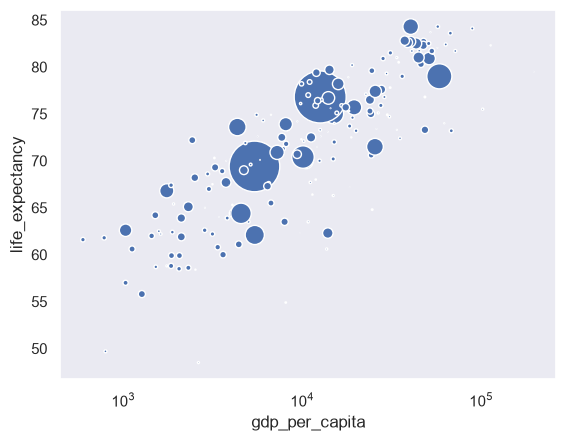

In [67]:
# same plot with better visibility
gm2015.plot.scatter(x='gdp_per_capita', y='life_expectancy', logx=True, s=1e-6 * gm2015.population,
                    edgecolor='w');

In [68]:
# define continents
continent = gm2015.region.map({'Africa': 'skyblue', 'Europe': 'gold', 'America': 'palegreen', 'Asia': 'coral', 'Oceania': 'teal'})
continent

199          coral
423           gold
647        skyblue
858           gold
1082       skyblue
           ...    
40960    palegreen
41183        coral
41381        coral
41605      skyblue
41813      skyblue
Name: region, Length: 195, dtype: str

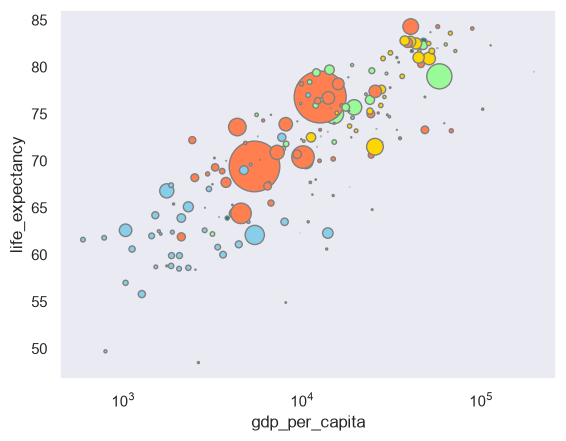

In [69]:
gm2015.plot.scatter(x='gdp_per_capita', y='life_expectancy', logx=True, s=1e-6 * gm2015.population,
                    c=continent, edgecolor='gray');

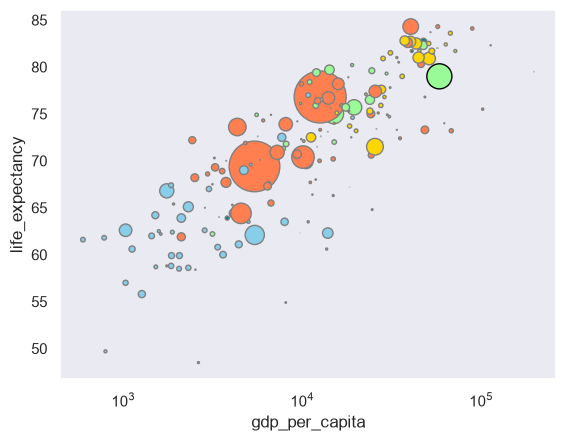

In [70]:
gm2015.plot.scatter(x='gdp_per_capita', y='life_expectancy', logx=True, s=1e-6 * gm2015.population,
                    c=continent, edgecolor=np.where(gm2015.country == "USA", 'black', 'gray'));

#### Create Interactive Plots

In [71]:
# import libraries
from ipywidgets import interactive, widgets

In [72]:
def plotyear(year, country):
    gm[gm.year == year].plot.scatter(x='gdp_per_capita', y='life_expectancy', logx=True, s=1e-6 * gm2015.population,
                                     c=continent, edgecolor=np.where(gm2015.country == country, 'black', 'gray'));
    plt.axis(xmin=200, xmax=200000, ymin=15, ymax=90); # fix the plotting ranges

In [73]:
interactive_plot = interactive(plotyear,
                               year=widgets.IntSlider(min=1950, max=2023, step=1, value=1950),
                               country=widgets.Dropdown(options=['USA', 'China', 'India']))

# some versions of Jupyter require workaround to keep the figure from jumping around
# interactive_plot.children[-1].layout.height = '400px'
interactive_plot

interactive(children=(IntSlider(value=1950, description='year', max=2023, min=1950), Dropdown(description='cou…

#### Summarizing and Visualizing Categorical Data

In [101]:
# import libraries
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [102]:
smoking = pd.read_csv('./whickham.csv')

In [103]:
smoking.shape

(1314, 3)

In [104]:
smoking.sample(10)

,age,smoker,outcome
610,20,No,Alive
779,58,Yes,Alive
1026,46,Yes,Alive
1084,60,Yes,Dead
133,37,No,Alive
1233,35,No,Alive
739,30,No,Alive
565,43,No,Dead
761,59,Yes,Dead
15,45,Yes,Alive


In [105]:
smoking.info()

<class 'pandas.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      1314 non-null   int64
 1   smoker   1314 non-null   str  
 2   outcome  1314 non-null   str  
dtypes: int64(1), str(2)
memory usage: 30.9 KB


In pandas, the str data type stores standard text data, while the category data type stores data using fixed integer codes for a limited set of unique values. The main differences are memory use, performance, and ordering rules.

In [106]:
# encoding the variables explicitly as categories will save memory and CPU
smoking.smoker = smoking.smoker.astype('category')
smoking.outcome = smoking.outcome.astype('category')

In [107]:
smoking.info()

<class 'pandas.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   age      1314 non-null   int64   
 1   smoker   1314 non-null   category
 2   outcome  1314 non-null   category
dtypes: category(2), int64(1)
memory usage: 13.0 KB


In [108]:
smoking.head(5)

,age,smoker,outcome
0,23,Yes,Alive
1,18,Yes,Alive
2,71,Yes,Dead
3,67,No,Alive
4,64,No,Alive


In [109]:
smoking.tail(5)

,age,smoker,outcome
1309,35,Yes,Alive
1310,33,No,Alive
1311,21,Yes,Alive
1312,46,No,Alive
1313,41,Yes,Alive


In [110]:
smoking.smoker.value_counts()

smoker
No     732
Yes    582
Name: count, dtype: int64

In [111]:
smoking.outcome.value_counts()

outcome
Alive    945
Dead     369
Name: count, dtype: int64

In [112]:
smoking.outcome.value_counts(normalize=True)

outcome
Alive    0.719178
Dead     0.280822
Name: proportion, dtype: float64

In [113]:
# specifying observer=True includes only categories that are represented in the data
# it makes no difference here but it suppressed a pandas warning

smoking.groupby("smoker", observed=True).outcome.value_counts(normalize=True)

smoker  outcome
No      Alive      0.685792
        Dead       0.314208
Yes     Alive      0.761168
        Dead       0.238832
Name: proportion, dtype: float64

In [114]:
smoking.groupby("smoker", observed=True).outcome.value_counts(normalize=True).unstack()

outcome,Alive,Dead
smoker,,
No,0.685792,0.314208
Yes,0.761168,0.238832


In [115]:
smoking['agegroup'] = pd.cut(smoking.age, bins=[15,40,65,90])
smoking['agegroup']

0       (15, 40]
1       (15, 40]
2       (65, 90]
3       (65, 90]
4       (40, 65]
          ...   
1309    (15, 40]
1310    (15, 40]
1311    (15, 40]
1312    (40, 65]
1313    (40, 65]
Name: agegroup, Length: 1314, dtype: category
Categories (3, interval[int64, right]): [(15, 40] < (40, 65] < (65, 90]]

In [116]:
smoking.agegroup.value_counts()

agegroup
(40, 65]    545
(15, 40]    540
(65, 90]    229
Name: count, dtype: int64

In [117]:
smoking.groupby(['agegroup', 'smoker'], observed=True).outcome.value_counts(normalize=True).unstack()

outcome             Alive      Dead
agegroup smoker                    
(15, 40] No      0.969900  0.030100
         Yes     0.958506  0.041494
(40, 65] No      0.739130  0.260870
         Yes     0.705479  0.294521
(65, 90] No      0.138889  0.861111
         Yes     0.122449  0.877551

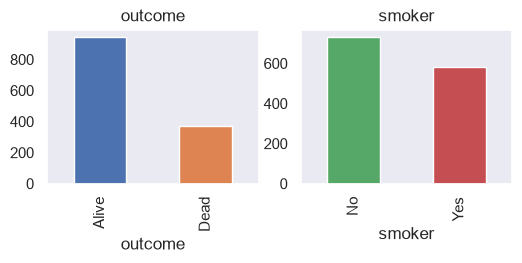

In [118]:
# plot the results
plt.figure(figsize=(6,2))

plt.subplot(1,2,1)
smoking.outcome.value_counts().plot(kind='bar', color=['C0','C1']) 
plt.title('outcome')

plt.subplot(1,2,2)
smoking.smoker.value_counts().plot(kind='bar', color=['C2','C3'])
plt.title('smoker');

<Axes: ylabel='outcome'>

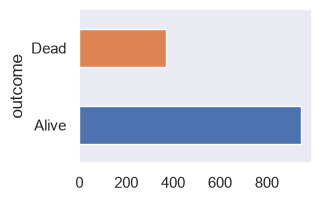

In [119]:
smoking.outcome.value_counts().plot(kind='barh', color=['C0','C1'], figsize=(3,2)) 

<Axes: >

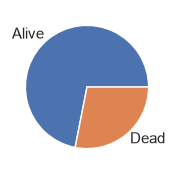

In [120]:
smoking.outcome.value_counts().plot(kind='pie', color=['C0','C1'], figsize=(3,2)) 

In [121]:
grouped = smoking.groupby("smoker", observed=True).outcome.value_counts(normalize=True).unstack()
grouped

outcome,Alive,Dead
smoker,,
No,0.685792,0.314208
Yes,0.761168,0.238832


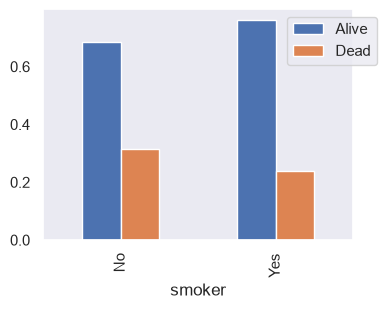

In [122]:
axes = grouped.plot(kind='bar', figsize=(4,3))
axes.legend(loc='upper right', bbox_to_anchor=(1.1, 1)); # fix legend location

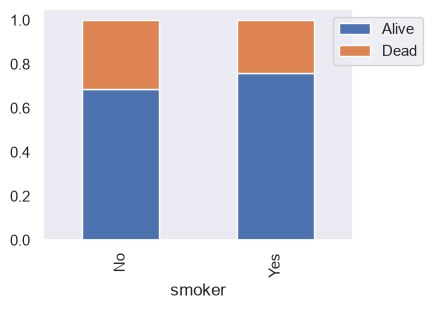

In [123]:
axes = grouped.plot(kind='bar', figsize=(4,3), stacked=True)
axes.legend(loc='upper right', bbox_to_anchor=(1.25, 1)); # fix legend location

In [124]:
regrouped = smoking.groupby(['agegroup', 'smoker'], observed=True).outcome.value_counts(normalize=True).unstack()
regrouped

outcome             Alive      Dead
agegroup smoker                    
(15, 40] No      0.969900  0.030100
         Yes     0.958506  0.041494
(40, 65] No      0.739130  0.260870
         Yes     0.705479  0.294521
(65, 90] No      0.138889  0.861111
         Yes     0.122449  0.877551

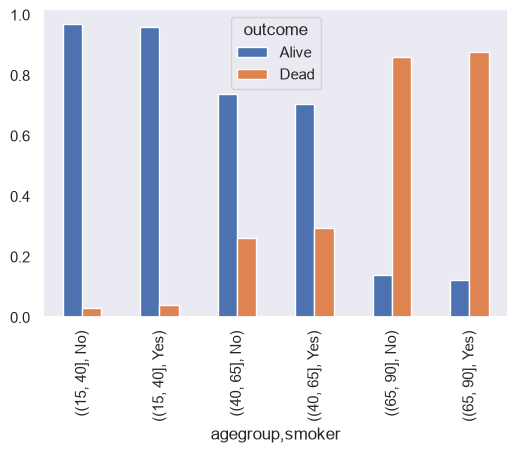

In [125]:
regrouped.plot(kind='bar', figsize=(6,4));

In [126]:
regrouped = smoking.groupby(['agegroup', 'smoker'], observed=True) \
                   .outcome.value_counts(normalize=True).loc[:,:,'Alive'].unstack()
regrouped

smoker,No,Yes
agegroup,,
"(15, 40]",0.969900,0.958506
"(40, 65]",0.739130,0.705479
"(65, 90]",0.138889,0.122449


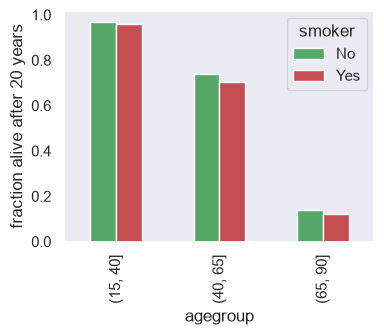

In [100]:
regrouped.plot(kind='bar', color=['C2','C3'], figsize=(4,3));
plt.ylabel('fraction alive after 20 years');